# LOSO CV: Batchwise SGD with Seasonal Interaction Kernel

Leave-One-Site-Out cross-validation using **batchwise SGD** training
following Patel et al. (2022, AAAI). Each epoch samples a fresh batch
from the full training set, providing implicit regularization — the model
can't memorize any single batch.

**Key difference from fixed-subset approach:** Previously we subsampled
training data once (e.g., 1000 or 4000 points) and trained on that fixed
subset. Here, the model sees ALL training data over the course of training,
with a different random batch each epoch.

**Kernel:** `Base_RBF_ARD + AOT×Season + SmogI/P×Season + Residual_Season`

In [1]:
import subprocess
import sys
import time

# Run parallel LOSO script
cmd = [
    sys.executable, 'loso_cv_parallel.py',
    '--batch_size', '4000',
    '--n_epochs', '200',
    '--patience', '20',
    '--n_gpus', '8',
]
print(f"Running: {' '.join(cmd)}")
start = time.perf_counter()
result = subprocess.run(cmd, capture_output=True, text=True)
elapsed = time.perf_counter() - start
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
print(f"\nScript finished in {elapsed:.1f}s")

Running: /home/vcaristo/miniconda3/envs/patel/bin/python loso_cv_parallel.py --batch_size 4000 --n_epochs 200 --patience 20 --n_gpus 8


Configuration: n_gpus=8, batch_size=4000, n_epochs=200, patience=20, inference_size=4000
Available CUDA devices: 4
Using 4 GPUs

15,572 observations, 32 sites
Training uses ALL data per fold (no subsampling), batch_size=4000 per epoch

Launching 32 folds across 4 GPUs...
  Fold  3 (GPU 3) site=115324_47594: R²=-1.442, epochs=120, n_train=14853, train=9.4s
  Fold  0 (GPU 0) site=115553_48392: R²=0.204, epochs=140, n_train=14846, train=11.3s
  Fold  2 (GPU 2) site=114158_46244: R²=0.141, epochs=200, n_train=14857, train=14.8s
  Fold  1 (GPU 1) site=114021_46842: R²=-0.162, epochs=199, n_train=14845, train=17.6s
  Fold  4 (GPU 0) site=112501_46003: R²=0.049, epochs=106, n_train=14842, train=8.7s
  Fold  5 (GPU 1) site=111092_44658: R²=-1.940, epochs=89, n_train=14851, train=9.5s
  Fold  7 (GPU 3) site=111303_47494: R²=0.266, epochs=85, n_train=14845, train=6.3s
  Fold  6 (GPU 2) site=112013_46659: R²=0.389, epochs=133, n_train=14842, train=9.6s
  Fold  8 (GPU 0) site=111056_45684: R²=-0.4

## Results

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('parallel_results.json') as f:
    results = json.load(f)

metrics_df = pd.read_csv('parallel_site_metrics.csv')
params_df = pd.read_csv('parallel_kernel_params.csv')
timing_df = pd.read_csv('parallel_fold_timings.csv')
data = np.load('parallel_predictions.npz')

print("=" * 60)
print("LOSO CV Results (Batchwise SGD, Seasonal Interaction)")
print("=" * 60)
o = results['overall']
c = results['config']
print(f"Training: batchwise SGD, batch_size={c['batch_size']}, patience={c['patience']}")
print(f"Log scale:  RMSE={o['rmse_log']:.4f}, MAE={o['mae_log']:.4f}, R²={o['r2_log']:.4f}")
print(f"Orig scale: RMSE={o['rmse_orig']:.2f}, MAE={o['mae_orig']:.2f}, R²={o['r2_orig']:.4f}")
print(f"Total time: {o['total_time']:.1f}s")
print(f"\nSite-level R² summary:")
print(metrics_df['r2_log'].describe())

LOSO CV Results (Batchwise SGD, Seasonal Interaction)
Training: batchwise SGD, batch_size=4000, patience=20
Log scale:  RMSE=0.6896, MAE=0.5196, R²=0.1384
Orig scale: RMSE=6.18, MAE=3.77, R²=0.1789
Total time: 105.6s

Site-level R² summary:
count    32.000000
mean     -1.397034
std       6.904257
min     -38.954042
25%      -0.589165
50%       0.116093
75%       0.398834
max       0.642708
Name: r2_log, dtype: float64


## Training Loss

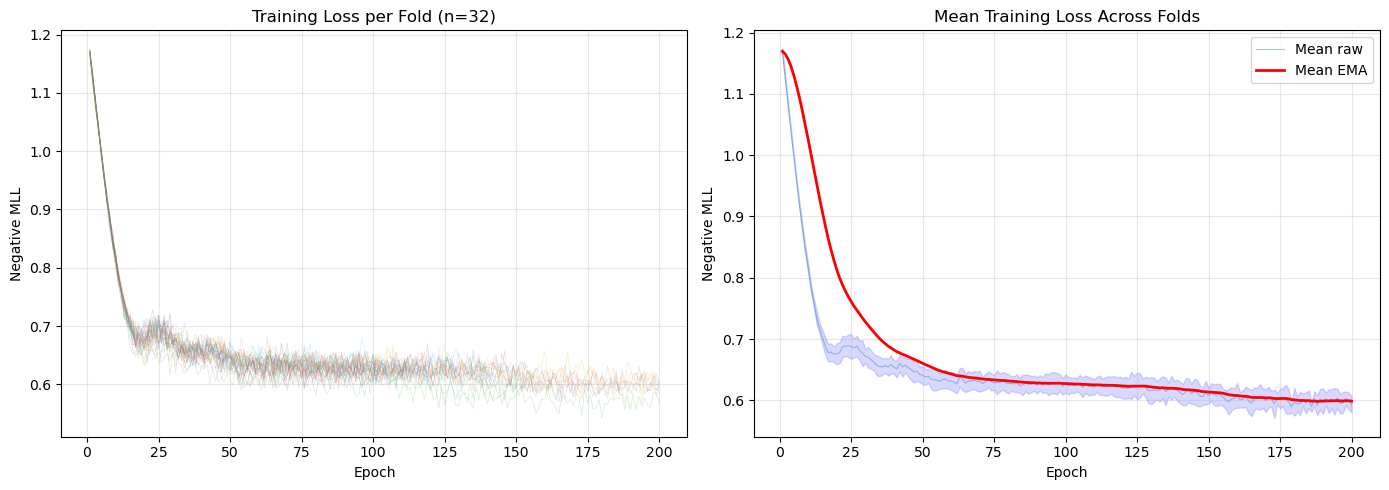

Min mean raw loss at epoch 179: 0.5898
Final mean EMA: 0.5988


In [3]:
fold_losses = results['fold_losses']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual fold loss curves
for site, losses in fold_losses.items():
    axes[0].plot(range(1, len(losses)+1), losses, alpha=0.2, linewidth=0.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative MLL')
axes[0].set_title(f'Training Loss per Fold (n={len(fold_losses)})')
axes[0].grid(True, alpha=0.3)

# Mean + EMA across folds
max_len = max(len(v) for v in fold_losses.values())
loss_matrix = np.full((len(fold_losses), max_len), np.nan)
for i, losses in enumerate(fold_losses.values()):
    loss_matrix[i, :len(losses)] = losses
mean_loss = np.nanmean(loss_matrix, axis=0)
std_loss = np.nanstd(loss_matrix, axis=0)
epochs = np.arange(1, len(mean_loss)+1)

# EMA of mean
ema = [mean_loss[0]]
for l in mean_loss[1:]:
    if not np.isnan(l):
        ema.append(0.9 * ema[-1] + 0.1 * l)
    else:
        ema.append(ema[-1])

axes[1].plot(epochs, mean_loss, alpha=0.4, linewidth=0.8, label='Mean raw')
axes[1].plot(epochs[:len(ema)], ema, 'r-', linewidth=2, label='Mean EMA')
axes[1].fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss,
                     alpha=0.15, color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Negative MLL')
axes[1].set_title('Mean Training Loss Across Folds')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

min_epoch = np.nanargmin(mean_loss) + 1
print(f"Min mean raw loss at epoch {min_epoch}: {np.nanmin(mean_loss):.4f}")
print(f"Final mean EMA: {ema[-1]:.4f}")

## Predictions

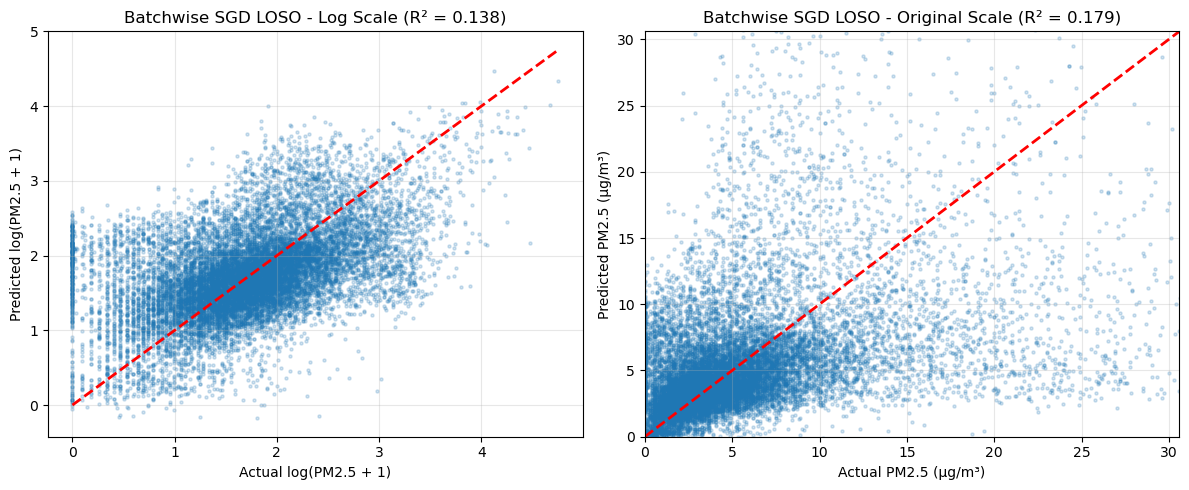

In [4]:
all_pred = data['predictions']
all_actual = data['actuals']
pred_pm25 = data['pred_pm25']
actual_pm25 = data['actual_pm25']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_actual, all_pred, alpha=0.2, s=5)
axes[0].plot([all_actual.min(), all_actual.max()],
             [all_actual.min(), all_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'Batchwise SGD LOSO - Log Scale (R² = {o["r2_log"]:.3f})')
axes[0].grid(True, alpha=0.3)

max_val = np.percentile(np.concatenate([actual_pm25, pred_pm25]), 99)
axes[1].scatter(actual_pm25, pred_pm25, alpha=0.2, s=5)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (μg/m³)')
axes[1].set_ylabel('Predicted PM2.5 (μg/m³)')
axes[1].set_title(f'Batchwise SGD LOSO - Original Scale (R² = {o["r2_orig"]:.3f})')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Site-Level Analysis

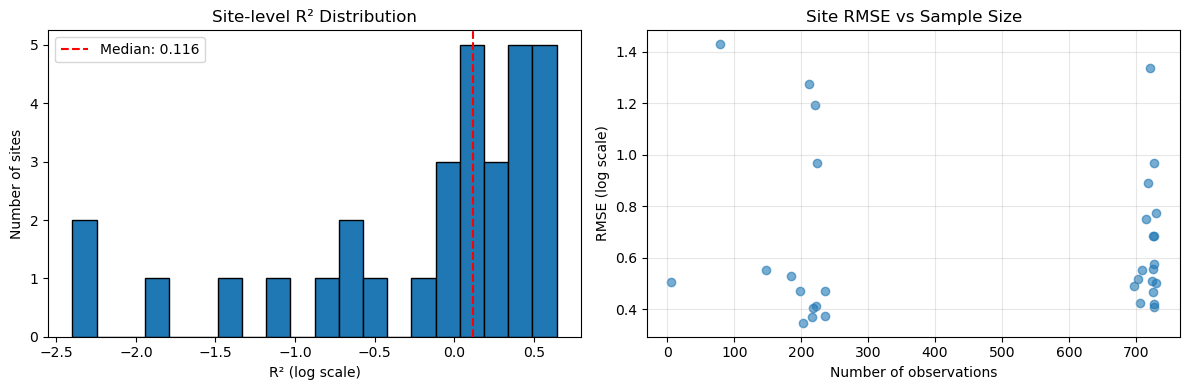


Top 5 best sites:
        site  n_obs  rmse_log   r2_log
114001_45860    236  0.375825 0.642708
115672_47955    218  0.405887 0.639504
104476_48487    216  0.370385 0.567630
108720_47582    222  0.414943 0.499426
114096_46927      6  0.507826 0.493911

Top 5 worst sites:
        site  n_obs  rmse_log     r2_log
115195_48971     78  1.429602 -38.954042
114270_47773    211  1.276306  -2.398862
113997_48510    221  1.195514  -2.346333
111092_44658    721  1.337502  -1.940389
115324_47594    719  0.891003  -1.442428


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

valid_r2 = metrics_df['r2_log'].dropna()
axes[0].hist(valid_r2[valid_r2 > -5], bins=20, edgecolor='black')
axes[0].axvline(x=valid_r2.median(), color='r', linestyle='--',
                label=f'Median: {valid_r2.median():.3f}')
axes[0].set_xlabel('R² (log scale)')
axes[0].set_ylabel('Number of sites')
axes[0].set_title('Site-level R² Distribution')
axes[0].legend()

axes[1].scatter(metrics_df['n_obs'], metrics_df['rmse_log'], alpha=0.6)
axes[1].set_xlabel('Number of observations')
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('Site RMSE vs Sample Size')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 5 best sites:")
print(metrics_df.nlargest(5, 'r2_log')[['site', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))
print("\nTop 5 worst sites:")
print(metrics_df.nsmallest(5, 'r2_log')[['site', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))

## Kernel Parameters

In [6]:
print("Learned kernel output scales (higher = more important):")
print(f"{'Component':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for col, label in [('base_scale', 'Base RBF_ARD'),
                    ('summer_scale', 'AOT x Season'),
                    ('winter_scale', 'SmogI/P x Season'),
                    ('seasonal_scale', 'Residual Seasonal')]:
    print(f"{label:<25} {params_df[col].mean():>8.4f} {params_df[col].std():>8.4f} "
          f"{params_df[col].min():>8.4f} {params_df[col].max():>8.4f}")

print(f"\nLearned periods (days):")
for col, label in [('aot_period_days', 'AOT periodic'),
                    ('smog_period_days', 'Smog periodic'),
                    ('residual_period_days', 'Residual periodic')]:
    print(f"{label:<25} {params_df[col].mean():>8.1f} {params_df[col].std():>8.1f} "
          f"{params_df[col].min():>8.1f} {params_df[col].max():>8.1f}")

print(f"\nEarly stopping: mean epochs = {timing_df['stopped_epoch'].mean():.1f}, "
      f"min = {timing_df['stopped_epoch'].min()}, max = {timing_df['stopped_epoch'].max()}")

Learned kernel output scales (higher = more important):
Component                     Mean      Std      Min      Max
------------------------------------------------------------
Base RBF_ARD                0.3096   0.0331   0.2322   0.3559
AOT x Season                0.1235   0.0218   0.0785   0.1664
SmogI/P x Season            0.0939   0.0233   0.0612   0.1557
Residual Seasonal           0.0227   0.0018   0.0166   0.0264

Learned periods (days):
AOT periodic                 209.9     33.2    136.0    294.1
Smog periodic                337.9     15.9    316.1    407.3
Residual periodic             44.2      7.3     24.0     62.7

Early stopping: mean epochs = 147.0, min = 85, max = 200
